# Salifort Motors — Employee Turnover Analysis
**Google Advanced Data Analytics Certificate | Capstone Project**  
**Author:** Johannes Kuhaupt  
**Date:** July 2026  

**Overview**
Analysis of HR survey data from 14,999 employees to predict voluntary
employee turnover using tree-based machine learning models.

**Key steps:**
- Exploratory Data Analysis (EDA) to identify drivers of attrition
- Preprocessing including encoding, outlier treatment and train/val/test split
- Four models trained and compared: Logistic Regression, Decision Tree,
  Random Forest and XGBoost
- Experiment tracking with MLflow
- Model evaluation and identification of the champion model
- Summary and recommendations
- Extension for practical model usage

## 1. Imports & Setup

In [158]:
# Installs
!pip install mlflow pyngrok -q

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn import metrics
from sklearn.metrics import ConfusionMatrixDisplay

# MLflow
import mlflow
import mlflow.sklearn
import mlflow.xgboost

# MLflow UI
import subprocess
import time
from pyngrok import ngrok

# Utilities
import os
import warnings
warnings.filterwarnings('ignore')
from datetime import datetime
import pytz

# Google Colab
from google.colab import drive
from google.colab import userdata

## 2. Load Data

In [107]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Salifort Motors Capstone Project/HR_comma_sep.csv')
df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [108]:
# Work on a copy to preserve the original
df1 = df.copy()

# Fix inconsistent column names for clarity and accuracy throughout the analysis
df1.columns = df.columns.str.lower()
df1 = df1.rename(columns={
    'average_montly_hours': 'average_monthly_hours',  # fix typo in original dataset
    'time_spend_company': 'tenure',                   # rename for clarity
    'sales': 'department'                             # rename for accuracy
})

df1.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## 3. Exploratory Data Analysis (EDA)

### 3.1 Dataset Overview
- df.shape, df.head(), df.info(), df.describe()
- Check missing values
- Check and remove duplicates

In [109]:
df1.shape

(14999, 10)

In [110]:
df1.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [111]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_monthly_hours  14999 non-null  int64  
 4   tenure                 14999 non-null  int64  
 5   work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [112]:
df1.describe()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [113]:
# Check for missing values
print(df1.isnull().sum())

satisfaction_level       0
last_evaluation          0
number_project           0
average_monthly_hours    0
tenure                   0
work_accident            0
left                     0
promotion_last_5years    0
department               0
salary                   0
dtype: int64


In [114]:
# Check for duplicates
print(f'Duplicate rows: {df1.duplicated().sum()}')

# Remove duplicates
df1 = df1.drop_duplicates()
print(f'Shape after removing duplicates: {df1.shape}')

Duplicate rows: 3008
Shape after removing duplicates: (11991, 10)


In [115]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11991 entries, 0 to 11999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     11991 non-null  float64
 1   last_evaluation        11991 non-null  float64
 2   number_project         11991 non-null  int64  
 3   average_monthly_hours  11991 non-null  int64  
 4   tenure                 11991 non-null  int64  
 5   work_accident          11991 non-null  int64  
 6   left                   11991 non-null  int64  
 7   promotion_last_5years  11991 non-null  int64  
 8   department             11991 non-null  object 
 9   salary                 11991 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.0+ MB


The dataset contained 3,008 duplicate rows (20% of the original 14,999 records),
which were removed before analysis. All subsequent analysis is based on
11,991 unique employee records. No missing values were detected across any column.

  ### 3.2 Correlation Heatmap
  - Identify potential relationships
  - Flag key variables for deeper investigation

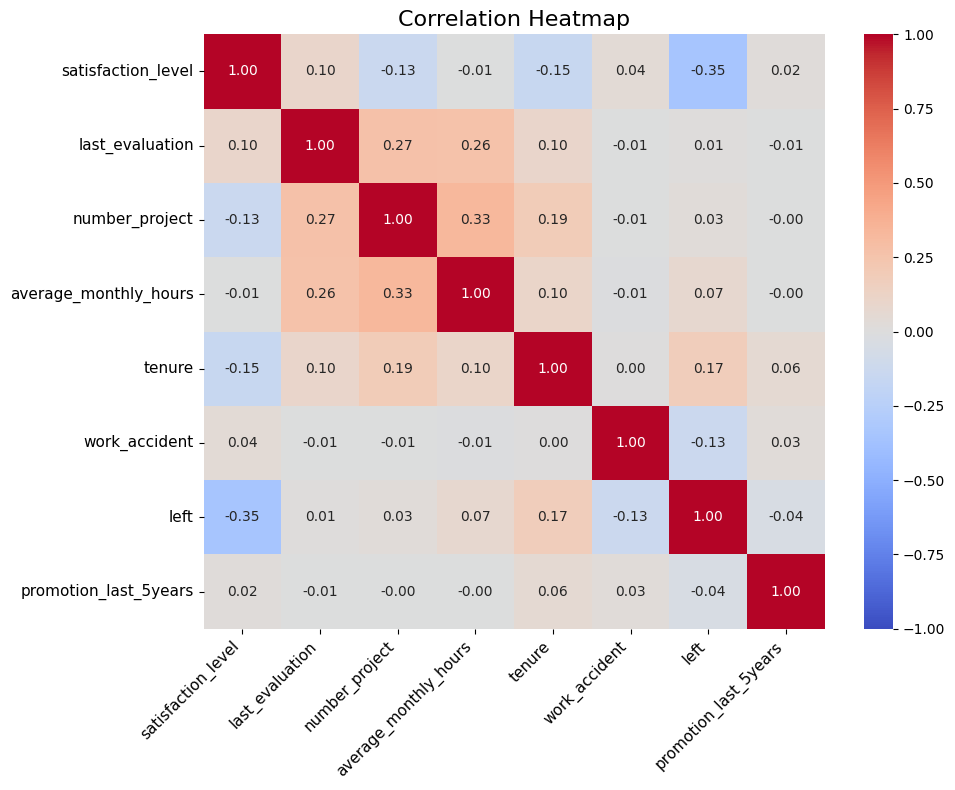

satisfaction_level      -0.350558
tenure                   0.173295
work_accident           -0.125436
average_monthly_hours    0.070409
promotion_last_5years   -0.044657
number_project           0.030928
last_evaluation          0.013520
Name: left, dtype: float64


In [116]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    df1.corr(numeric_only=True),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)

plt.title('Correlation Heatmap', fontsize=16)
plt.xticks(fontsize=11, rotation=45, ha='right')
plt.yticks(fontsize=11, rotation=0)

plt.tight_layout()
plt.show()

# Extract correlations with target variable left
target_corr = df1.select_dtypes(include='number').corr()['left'].drop('left')
target_corr = target_corr.sort_values(key=abs, ascending=False)
print(target_corr)

### 3.2 Key Variables Flagged for Deeper Investigation

Based on the correlation with the target variable `left`:

| Variable | Correlation | Interpretation |
|---|---|---|
| `satisfaction_level` | −0.39 | Strongest predictor — low satisfaction drives leaving |
| `work_accident` | −0.15 | Employees with accidents slightly less likely to leave |
| `tenure` | +0.14 | Certain tenure bands show higher attrition risk |
| `average_monthly_hours` | +0.07 | Weak linear correlation but non-linear patterns possible |
| `number_project` | +0.02 | Weak linear correlation but non-linear patterns possible |
| `last_evaluation` | +0.01 | Near zero linear correlation — non-linear effects should be investigated |

**Note:** Low linear correlation does not mean low predictive importance. The variables `number_project` and `average_monthly_hours` will show a significant impact in tree-based models due to non-linear relationships.

### 3.3 Target Variable Distribution
- Count and proportion of stayed vs left
- Histogram of left


In [117]:
# Count and proportion of stayed vs left

counts = df1['left'].value_counts()
proportions = df1['left'].value_counts(normalize=True).round(3)

summary = pd.DataFrame({'count': counts, 'proportion': proportions})
summary.index = ['Stayed', 'Left']
print(summary)

        count  proportion
Stayed  10000       0.834
Left     1991       0.166


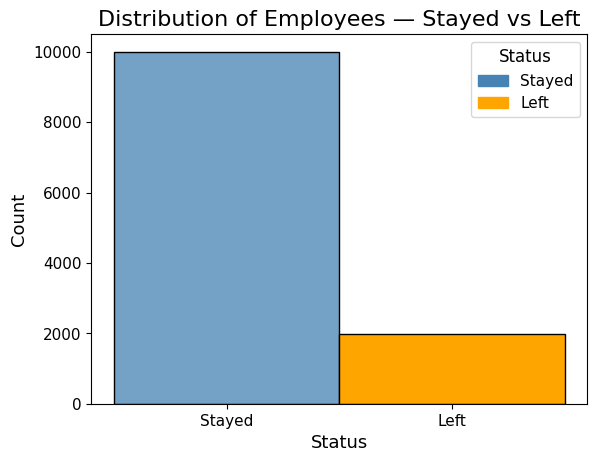

In [118]:
# Histogram of left

ax = sns.histplot(
    data=df1,
    x='left',
    discrete=True,
    color='steelblue'
)

# Manually recolor the second bar
ax.patches[1].set_facecolor('orange')

plt.title('Distribution of Employees — Stayed vs Left', fontsize=16)
plt.xlabel('Status', fontsize=13)
plt.ylabel('Count', fontsize=13)
plt.xticks(ticks=[0, 1], labels=['Stayed', 'Left'], fontsize=11)
plt.yticks(fontsize=11)

legend_handles = [
    mpatches.Patch(color='steelblue', label='Stayed'),
    mpatches.Patch(color='orange', label='Left')
]
plt.legend(handles=legend_handles, title='Status', fontsize=11, title_fontsize=12)

plt.show()


The dataset is imbalanced as 76% of employees stayed and 24% left. This will be considered in the modeling phase via `class_weight='balanced'` for Logistic Regression and F1 as the primary evaluation metric across all models.

  ### 3.4 Satisfaction & Workload Analysis
  - Mean & median satisfaction by group
  - Monthly hours vs satisfaction scatterplot (with mean hours line)
  - Satisfaction by tenure boxplot
  


In [119]:
# Mean & median satisfaction by group

df1.groupby('left')['satisfaction_level'].agg(['mean', 'median']).rename(index={0: 'Stayed', 1: 'Left'}).round(2)

,mean,median
left,,
Stayed,0.67,0.69
Left,0.44,0.41


Employees who left had a significantly lower mean satisfaction level (0.44)
compared to those who stayed (0.67) — a difference of 0.23 points.
The median shows a similar difference (0.41 vs 0.69), reflecting a structural difference between the two groups.

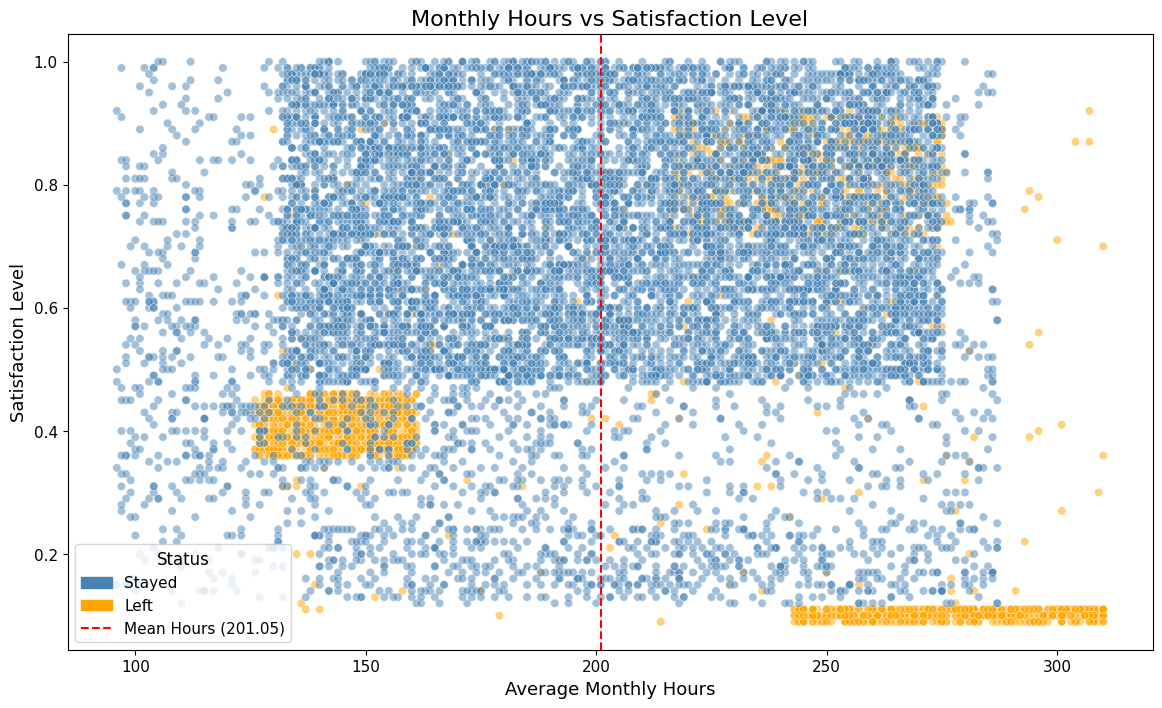

In [120]:
# Scatterplot: monthly hours vs satisfaction scatterplot (with mean hours line)

plt.figure(figsize=(14, 8))

sns.scatterplot(
    data=df1,
    x='average_monthly_hours',
    y='satisfaction_level',
    hue='left',
    palette={0: 'steelblue', 1: 'orange'},
    alpha=0.5
)

plt.axvline(x=201.05, color='red', linestyle='--', linewidth=1.5)

plt.title('Monthly Hours vs Satisfaction Level', fontsize=16)
plt.xlabel('Average Monthly Hours', fontsize=13)
plt.ylabel('Satisfaction Level', fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

legend_handles = [
    mpatches.Patch(color='steelblue', label='Stayed'),
    mpatches.Patch(color='orange', label='Left'),
    plt.Line2D([0], [0], color='red', linestyle='--', linewidth=1.5, label='Mean Hours (201.05)')
]
plt.legend(handles=legend_handles, title='Status', fontsize=11, title_fontsize=12)

plt.show()

The scatterplot reveals three distinct clusters of employees who left:

1. **Underworked & dissatisfied** — below average monthly hours (approx. 125–160)
   paired with low satisfaction levels (around 0.4), indicating these employees
   may have felt underutilized or disengaged.

2. **Overworked & burned out** — very high working hours (circa >250) combined
   with very low satisfaction (below 0.2), a classic burnout pattern.

3. **Overworked but satisfied** — above average hours (approx. 200–275) with
   high satisfaction levels (above 0.7), possibly high performers who left for
   better opportunities despite being engaged.

Employees who stayed are broadly distributed across average hours (approx. 130–275) and higher satisfaction levels (circa 0.5 and above), suggesting that a healthy workload combined with adequate satisfaction drives retention.

**Key insight:** attrition is not driven by a single profile — three distinct employee types are at risk, each requiring different retention strategies.

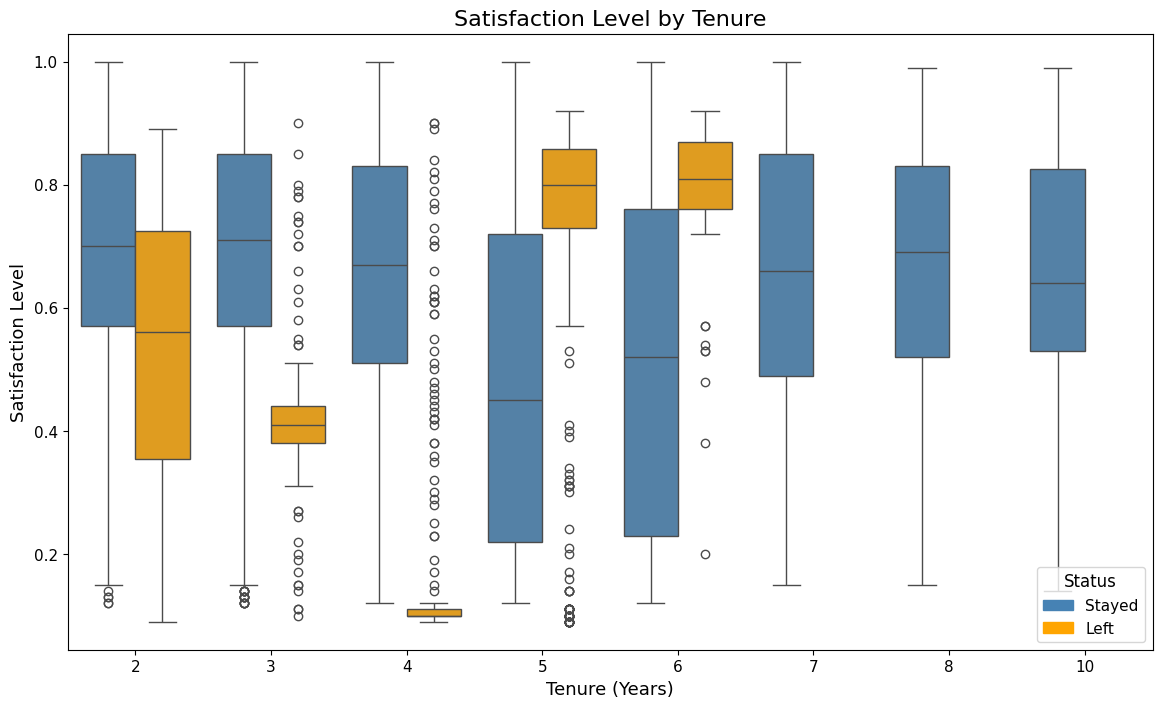

In [121]:
# Boxplot: satisfaction by tenure boxplot

plt.figure(figsize=(14, 8))

sns.boxplot(
    data=df1,
    x='tenure',
    y='satisfaction_level',
    hue='left',
    palette={0: 'steelblue', 1: 'orange'}
)

plt.title('Satisfaction Level by Tenure', fontsize=16)
plt.xlabel('Tenure (Years)', fontsize=13)
plt.ylabel('Satisfaction Level', fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

legend_handles = [
    mpatches.Patch(color='steelblue', label='Stayed'),
    mpatches.Patch(color='orange', label='Left')
]
plt.legend(handles=legend_handles, title='Status', fontsize=11, title_fontsize=12,
           loc='lower right')

plt.show()

The boxplot reveals distinct satisfaction and tenure patterns between the two groups:

**Employees who left:**
- Maximum tenure of 6 years — no leavers beyond this point
- The largest leaving group had a tenure of 2 years with a wide satisfaction
  range (approx. 0.35–0.7), suggesting mixed reasons for leaving early
- 3 and 4-year tenure employees left with notably low satisfaction
  (around 0.4 and below 0.1 respectively) — a potential sign of unmet
  expectations after the initial period
- Employees with 5 and 6 years tenure who left showed surprisingly high
  satisfaction (around 0.8), suggesting these are high performers who left
  for external opportunities rather than dissatisfaction

**Employees who stayed:**
- Tenure ranges broadly from 2 to 10 years with generally high satisfaction
  (0.5 and above)
- Exception: 5 and 6-year tenure employees show a wide satisfaction range
  (around 0.2–0.8), overlapping with the leavers in the same tenure band —
  this requires further investigation

**Key insight:** tenure alone does not predict attrition. The 5–6 year
band is particularly complex, containing both highly satisfied leavers
and a broad range of stayers, suggesting that other factors such as
career development opportunities and workload play a decisive role
at this tenure stage.

  ### 3.5 Workload Deep Dive
  - Monthly hours by number of projects boxplot
  - Number of projects histogram
  - Employees with 7 projects analysis


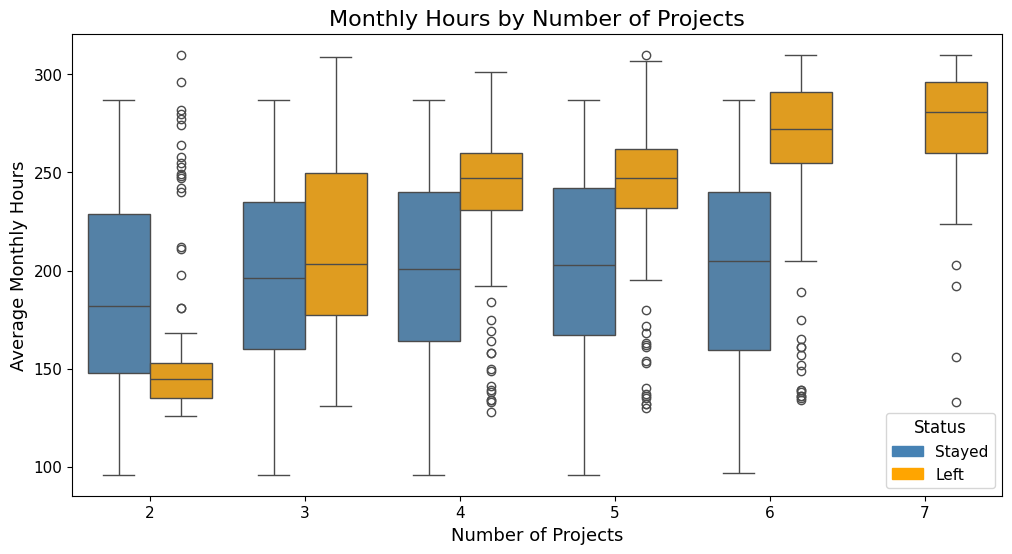

In [122]:
# Boxplot: average monthly hours by number of projects, split by attrition status

fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(
    data=df1,
    x='number_project',
    y='average_monthly_hours',
    hue='left',
    palette={0: 'steelblue', 1: 'orange'},
    ax=ax
)

plt.title('Monthly Hours by Number of Projects', fontsize=16)
plt.xlabel('Number of Projects', fontsize=13)
plt.ylabel('Average Monthly Hours', fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

legend_handles = [
    mpatches.Patch(color='steelblue', label='Stayed'),
    mpatches.Patch(color='orange', label='Left')
]
ax.legend(handles=legend_handles, title='Status', fontsize=11, title_fontsize=12)

plt.show()

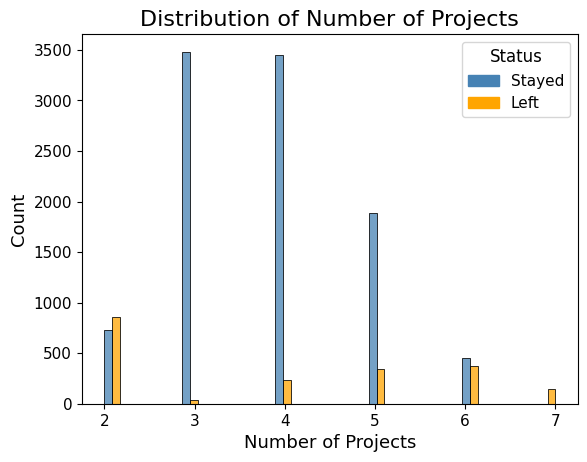

In [123]:
# Histogram: distribution of project count by attrition status

sns.histplot(
    data=df1,
    x='number_project',
    hue='left',
    palette={0: 'steelblue', 1: 'orange'},
    multiple='dodge'
)

plt.title('Distribution of Number of Projects', fontsize=16)
plt.xlabel('Number of Projects', fontsize=13)
plt.ylabel('Count', fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

legend_handles = [
    mpatches.Patch(color='steelblue', label='Stayed'),
    mpatches.Patch(color='orange', label='Left')
]
plt.legend(handles=legend_handles, title='Status', fontsize=11, title_fontsize=12)

plt.show()

The histogram reveals two distinctly different project distributions between the two groups:

**Employees who stayed** follow an approximate normal distribution, peaking at 3–4 projects and decreasing towards 6, suggesting a balanced workload is associated with retention.

**Employees who left** show a bimodal pattern:
- The largest group had only **2 projects**, pointing to disengagement
  and underutilization as a driver of attrition
- Turnover increases again at **5–7 projects**, indicating that
  excessive workload is a problem

**Key insights:**
- All 145 employees with 7 projects left the company — a strong signal of burnout-driven attrition
- A risk for leaving exists at **both extremes** of the workload spectrum: too few projects leads to disengagement, too many leads to burnout
- The optimal range for retention appears to be **3–4 projects**

In [124]:
# Check: employees with 7 projects — did any stay?

print(df1[df1['number_project'] == 7]['left'].value_counts())
print()
print(df1[df1['number_project'] == 7]['left'].value_counts(normalize=True).round(3))

left
1    145
Name: count, dtype: int64

left
1    1.0
Name: proportion, dtype: float64


This check of employees with 7 projects confirms that all 145 employees with 7 projects left. This supports the impression that this number of projects leads to burnout and triggers employee attrition.

  ### 3.6 Tenure Analysis
  - Tenure histogram
  - Salary level by tenure histogram


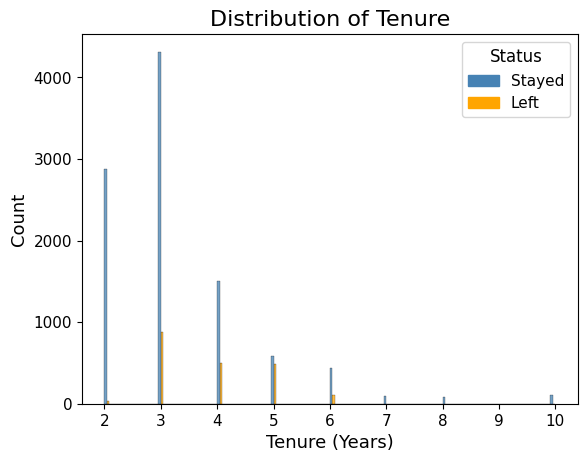

In [125]:
sns.histplot(
    data=df1,
    x='tenure',
    hue='left',
    palette={0: 'steelblue', 1: 'orange'},
    multiple='dodge'
)

plt.title('Distribution of Tenure', fontsize=16)
plt.xlabel('Tenure (Years)', fontsize=13)
plt.ylabel('Count', fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

legend_handles = [
    mpatches.Patch(color='steelblue', label='Stayed'),
    mpatches.Patch(color='orange', label='Left')
]
plt.legend(handles=legend_handles, title='Status', fontsize=11, title_fontsize=12)

plt.show()

The tenure histogram shows that both groups are concentrated in the
2–6 year range, with a shared peak at 3 years.

**Employees who stayed** show a gradual decline after year 3 but
maintain a presence across all tenure bands up to 10 years, indicating
long-term retention is achievable.

**Employees who left** are entirely concentrated between 2–6 years,
with no employee leaving after year 6. The distribution peaks at
3 years before declining steadily.

**Key insight:** years 3–5 represent the most critical window for
retention. Employees who pass the 6-year mark appear to commit
long-term, suggesting that targeted retention measures should focus
on employees in their third to fifth year — for example through
career development opportunities, workload reviews and regular
satisfaction check-ins.

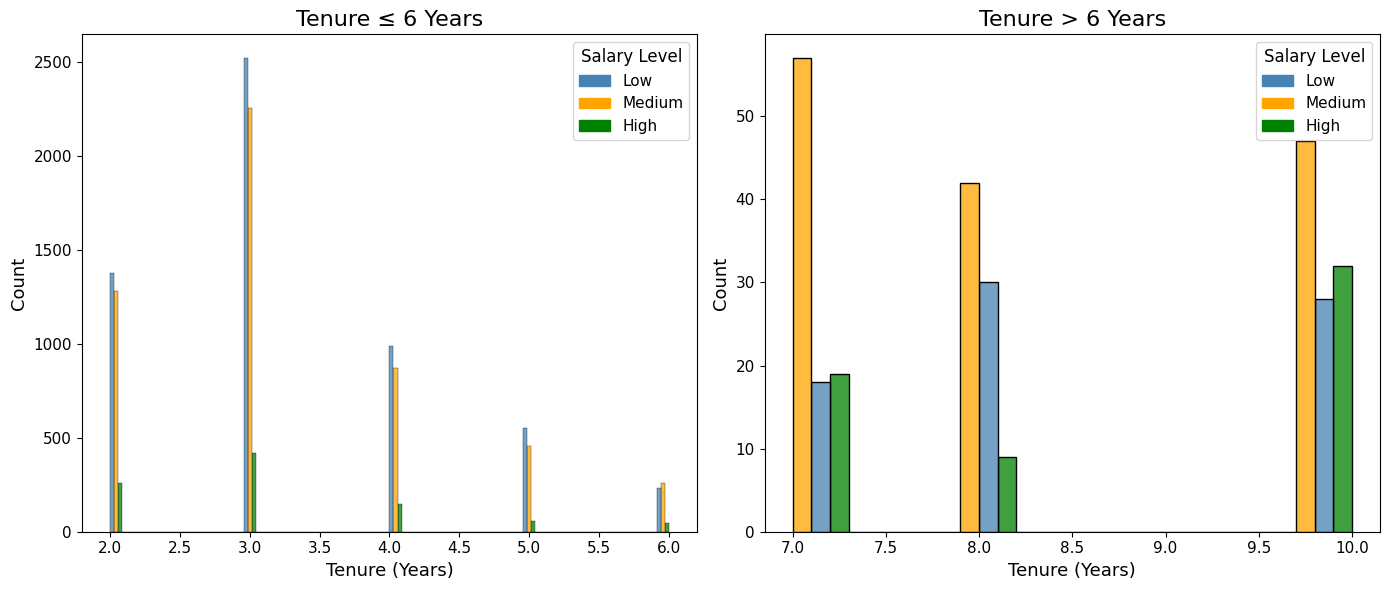

In [126]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

legend_handles = [
    mpatches.Patch(color='steelblue', label='Low'),
    mpatches.Patch(color='orange', label='Medium'),
    mpatches.Patch(color='green', label='High')
]

for ax, (mask, title) in zip(axes, [
    (df1['tenure'] <= 6, 'Tenure ≤ 6 Years'),
    (df1['tenure'] > 6, 'Tenure > 6 Years')
]):
    sns.histplot(
        data=df1[mask],
        x='tenure',
        hue='salary',
        palette={'low': 'steelblue', 'medium': 'orange', 'high': 'green'},
        multiple='dodge',
        ax=ax
    )
    ax.set_title(title, fontsize=16)
    ax.set_xlabel('Tenure (Years)', fontsize=13)
    ax.set_ylabel('Count', fontsize=13)
    ax.tick_params(labelsize=11)
    ax.legend(handles=legend_handles, title='Salary Level',
              fontsize=11, title_fontsize=12)

plt.tight_layout()
plt.show()

The salary histograms reveal a clear compensation pattern across tenure:

- **Low salary dominates** the ≤6 year tenure duration, particularly at years 2–5 where attrition is highest
- All salary groups peak at 3 years then decline, but the low salary group decreases faster, giving medium salary the majority from year 6 onwards
- The high salary group remains the smallest over the entire period, with a notable rise only at 10 years of tenure

**Connection to attrition:** since all leavers had a maximum tenure of 6 years, they fall entirely within the low-salary dominated band. This suggests that **low compensation during the critical 3–5 year window** may reinforce dissatisfaction and accelerate the decision to leave — even though salary showed near-zero linear correlation with attrition in the heatmap, its interaction with tenure makes it a contextually relevant factor.

  ### 3.7 Attrition by Department
  - Attrition rate by department
  - Visualisation as a bar chart

In [127]:
# Attrition rate by department
dept_attrition = df1.groupby('department')['left'].mean().sort_values(ascending=False).round(3)
print(dept_attrition)

department
hr             0.188
accounting     0.176
technical      0.174
support        0.171
sales          0.170
marketing      0.166
IT             0.162
product_mng    0.160
RandD          0.122
management     0.119
Name: left, dtype: float64


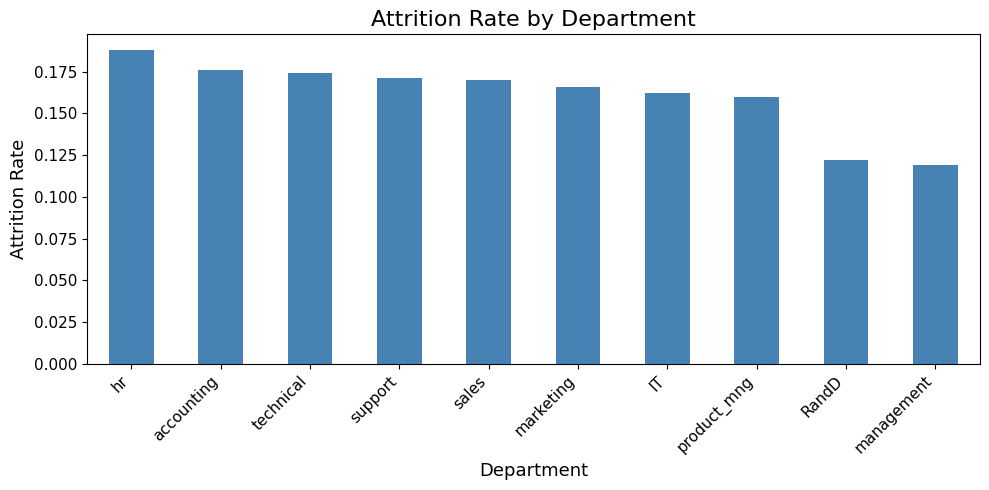

In [128]:
dept_attrition.plot(kind='bar', color='steelblue', figsize=(10, 5))
plt.title('Attrition Rate by Department', fontsize=16)
plt.xlabel('Department', fontsize=13)
plt.ylabel('Attrition Rate', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

Attrition rates are broadly consistent across all departments, ranging narrowly from approximately 12% (Management, RandD) to 19% (HR). This near-uniform distribution indicates that department is not a significant driver of attrition at Salifort Motors — turnover appears to be a company-wide issue rather than isolated to specific teams.

**Consequence for modeling:** department will be included in the model via one-hot encoding for completeness, but is not expected to carry significant predictive importance — consistent with the near-zero correlations observed in the heatmap.

### 3.8 Summary of EDA Findings

**Key Insights:**

1. **Satisfaction is the strongest driver of attrition** — employees who left
   showed significantly lower mean (0.44 vs 0.67) and median (0.41 vs 0.69)
   satisfaction levels, confirming the strongest correlation in the heatmap (−0.39).
   Employee satisfaction clearly has a strong impact on attrition.

2. **Three distinct leaver profiles emerge** from the hours vs satisfaction analysis:
   - *Underworked & dissatisfied* — below average hours (approx. 125–160)
     paired with low satisfaction (around 0.4), suggesting disengagement
   - *Overworked & burned out* — very high hours (above 250) with very low
     satisfaction (below 0.2), a classic burnout pattern
   - *Overworked but satisfied* — above average hours (approx. 200–275) with
     high satisfaction (above 0.7), likely high performers leaving for better
     external opportunities despite being engaged

3. **Workload extremes drive attrition** — employees who stayed follow an
   approximate normal distribution peaking at 3–4 projects, while leavers
   show a bimodal pattern: the largest group had only 2 projects (disengagement)
   while attrition increases again at 5–7 projects (burnout). All 145 employees
   with 7 projects left — an clear signal of burnout-driven attrition.

4. **Tenure is a decisive factor** — all leavers left within the first 6 years,
   with years 3–5 being the most critical window. Employees past year 6 appear
   to commit long-term. The 5–6 year band is particularly complex, containing
   high-satisfaction leavers who likely left for better external opportunities
   rather than dissatisfaction.

5. **Salary is an indirect rather than direct factor** — while showing near-zero
   linear correlation with attrition in the heatmap, low salary dominates the
   critical 3–5 year tenure band where most attrition occurs, suggesting that
   low compensation may reinforce dissatisfaction during the most decisive period.

**Bridge to Preprocessing:**
These findings inform the following preprocessing decisions:
- Tree-based models are preferred given the non-linear patterns observed
- `salary` will be ordinally encoded (low=0, medium=1, high=2) to preserve order
- `department` will be one-hot encoded as no natural order exists
- Winsorization will be applied for Logistic Regression only — tree-based models are robust to outliers
- F1 score will be used as the primary evaluation metric given class imbalance (76/24 split)

## 4. Data Preprocessing


### 4.1 Encode Categorical Variables
- Ordinal encoding for `salary` (low=0, medium=1, high=2)
- One-hot encoding for `department` using `pd.get_dummies(drop_first=True)`
- Drop original `salary` column


In [129]:
df2 = df1.copy()

# Ordinal encoding for salary — preserves natural order
salary_map = {'low': 0, 'medium': 1, 'high': 2}
df2['salary_encoded'] = df2['salary'].map(salary_map)
df2 = df2.drop(columns='salary')

# One-hot encoding for department — no natural order exists
df2 = pd.get_dummies(df2, columns=['department'], drop_first=True)

df2.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,salary_encoded,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,1,0,0,False,False,False,False,False,False,True,False,False
1,0.80,0.86,5,262,6,0,1,0,1,False,False,False,False,False,False,True,False,False
2,0.11,0.88,7,272,4,0,1,0,1,False,False,False,False,False,False,True,False,False
3,0.72,0.87,5,223,5,0,1,0,0,False,False,False,False,False,False,True,False,False
4,0.37,0.52,2,159,3,0,1,0,0,False,False,False,False,False,False,True,False,False



### 4.2 Outlier Treatment
- IQR-based winsorization for Logistic Regression
- Note: skipped for tree-based models as they are robust to outliers



In [130]:
# Winsorization applied for Logistic Regression only
# Tree-based models are robust to outliers — no treatment needed

numeric_cols = ['satisfaction_level', 'last_evaluation', 'number_project',
                'average_monthly_hours', 'tenure']

df2_lr = df2.copy()  # separate copy for logistic regression

for col in numeric_cols:
    Q1 = df2_lr[col].quantile(0.25)
    Q3 = df2_lr[col].quantile(0.75)
    IQR = Q3 - Q1
    df2_lr[col] = df2_lr[col].clip(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)

Winsorization caps extreme values at the 1.5×IQR boundary to reduce
the effect of outliers on model coefficients. This is applied to
Logistic Regression only, as tree-based models split on thresholds
and are inherently robust to extreme values.

### 4.3 Define Features and Target
- Separate feature matrix `X` from target variable `y` (`left`)
- Verify class imbalance with `value_counts()`


In [131]:
# Tree-based models
X = df2.drop(columns='left')
y = df2['left']

# Logistic Regression
X_lr = df2_lr.drop(columns='left')
y_lr = df2_lr['left']

# Verify class imbalance
print(y.value_counts(normalize=True).round(3))

left
0    0.834
1    0.166
Name: proportion, dtype: float64


### 4.4 Train / Validation / Test Split
- 60/20/20 split with `stratify=y` to preserve class balance
- Random state fixed at 42 for reproducibility


In [132]:
from sklearn.model_selection import train_test_split

# Tree-based models — 60/20/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, stratify=y_train, random_state=42)

# Logistic Regression
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y_lr, test_size=0.2, stratify=y_lr, random_state=42)
X_train_lr, X_val_lr, y_train_lr, y_val_lr = train_test_split(
    X_train_lr, y_train_lr, test_size=0.25, stratify=y_train_lr, random_state=42)

print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')

Train: (7194, 17), Val: (2398, 17), Test: (2399, 17)


The data is split into training (60%), validation (20%) and test (20%)
sets. `stratify=y` ensures that the same class distribution of the
target variable `left` (76% stayed, 24% left) is preserved across
all three sets, preventing any subset from being unrepresentative
of the overall population.

### 4.5 Feature Scaling
- `StandardScaler` applied for Logistic Regression only
- Fit on training data, transform validation and test sets
- Note: not required for tree-based models

In [133]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on training data only — avoid data leakage
X_train_lr_scaled = scaler.fit_transform(X_train_lr)
X_val_lr_scaled = scaler.transform(X_val_lr)
X_test_lr_scaled = scaler.transform(X_test_lr)

print('Scaling complete')

Scaling complete


StandardScaler is applied to standardize features to a mean of 0
and standard deviation of 1, as the dataset contains variables on
different scales (e.g. `satisfaction_level` ranges from 0–1 while
`average_monthly_hours` ranges from 90–310). The scaler is fitted
exclusively on the training data and then applied to the validation
and test sets to prevent data leakage.

## 5. Modeling


  ### 5.1 Logistic Regression



The first model used is Logistic Regression — a supervised machine learning
algorithm for binary classification problems. It predicts the probability
that an input belongs to one of two possible categories: in this case
**stayed (0)** or **left (1)**.

Unlike tree-based models, Logistic Regression assumes a linear relationship
between the features and the target variable. It serves as a useful
**baseline model** — if tree-based models significantly outperform it,
this confirms that non-linear patterns are driving attrition.

`class_weight='balanced'` assigns weights inversely proportional to class
frequencies — the minority class (Left, 24%) receives a higher weight and
the majority class (Stayed, 76%) receives a lower weight. This penalizes
misclassification of leavers more heavily during training, pushing the model
to catch more employees at risk of leaving rather than defaulting to
predicting the majority class.

Logistic Regression — Validation Set
              precision    recall  f1-score   support

           0       0.97      0.78      0.87      2000
           1       0.44      0.87      0.59       398

    accuracy                           0.80      2398
   macro avg       0.71      0.83      0.73      2398
weighted avg       0.88      0.80      0.82      2398



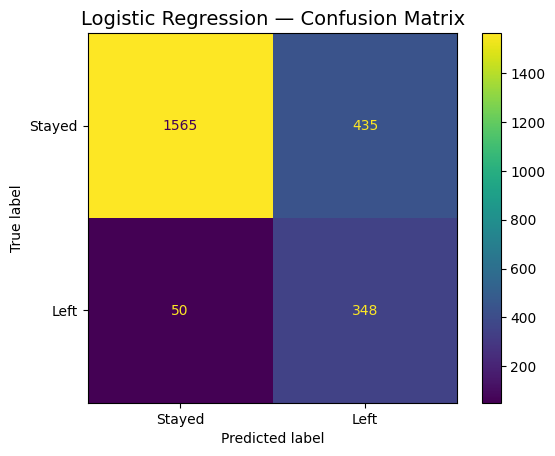

In [134]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

# Fit model
log_reg = LogisticRegression(random_state=42, max_iter=500, class_weight='balanced')
log_reg.fit(X_train_lr_scaled, y_train_lr)

# Evaluate on validation set
y_pred_lr = log_reg.predict(X_val_lr_scaled)
print('Logistic Regression — Validation Set')
print(metrics.classification_report(y_val_lr, y_pred_lr))

# Confusion matrix
cm_lr = metrics.confusion_matrix(y_val_lr, y_pred_lr)
metrics.ConfusionMatrixDisplay(cm_lr, display_labels=['Stayed', 'Left']).plot(values_format='d')
plt.title('Logistic Regression — Confusion Matrix', fontsize=14)
plt.show()

  ### 5.2 Decision Tree


A Decision Tree is a supervised machine learning algorithm that splits
the data into subsets based on feature values, creating a tree-like
structure of decisions. Each internal node represents a feature, each
branch represents a decision rule, and each leaf node represents an
outcome (stayed or left).

Unlike Logistic Regression, Decision Trees capture **non-linear relationships**
and feature interactions without requiring scaling or encoding assumptions.
They are highly interpretable — the tree structure can be visualized and
explained to non-technical stakeholders.

The main risk of Decision Trees is **overfitting** — a single tree can
memorize the training data rather than learning generalizable patterns.
`GridSearchCV` with `StratifiedKFold(n_splits=5)` is used to tune
hyperparameters and control overfitting by limiting tree depth and
minimum sample sizes. `StratifiedKFold(n_splits=5)` splits the data
into 5 folds, ensuring each fold maintains the same class distribution
(76% stayed, 24% left) as the full dataset — critical for imbalanced
classification problems.

Best parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10}
Best F1 score: 0.936

Decision Tree — Validation Set
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2000
           1       0.96      0.93      0.95       398

    accuracy                           0.98      2398
   macro avg       0.97      0.96      0.97      2398
weighted avg       0.98      0.98      0.98      2398



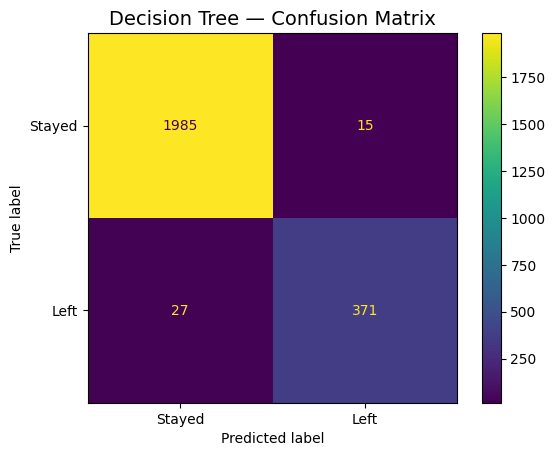

In [135]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

dt = DecisionTreeClassifier(random_state=42)

param_grid_dt = {
    'max_depth': [3, 5, 10, None],
    'min_samples_leaf': [1, 2, 5, 10],
    'min_samples_split': [2, 5, 10]
}

grid_search_dt = GridSearchCV(dt, param_grid_dt, cv=5, scoring='f1', n_jobs=-1)
grid_search_dt.fit(X_train, y_train)

print('Best parameters:', grid_search_dt.best_params_)
print('Best F1 score:', grid_search_dt.best_score_.round(3))

# Evaluate on validation set
best_dt = grid_search_dt.best_estimator_
y_pred_dt = best_dt.predict(X_val)
print('\nDecision Tree — Validation Set')
print(metrics.classification_report(y_val, y_pred_dt))

# Confusion matrix
cm_dt = metrics.confusion_matrix(y_val, y_pred_dt)
metrics.ConfusionMatrixDisplay(cm_dt, display_labels=['Stayed', 'Left']).plot(values_format='d')
plt.title('Decision Tree — Confusion Matrix', fontsize=14)
plt.show()

  ### 5.3 Random Forest


Random Forest is an ensemble method that builds multiple Decision Trees
and combines their predictions via majority vote. It addresses the
overfitting problem of single Decision Trees through two mechanisms:

- **Bagging (Bootstrap Aggregating)** — each tree is trained on a random
  sample of the data with replacement, reducing variance
- **Random Feature Selection (Feature Bagging)** — each split considers
  only a random subset of features, decorrelating the trees and preventing
  any single dominant feature from driving all predictions

The final prediction is the majority vote across all trees.

The result is a more robust and generalizable model than a single Decision
Tree, at the cost of some interpretability. `GridSearchCV` with
`StratifiedKFold(n_splits=5)` is used to tune the number of trees
(`n_estimators`), tree depth and minimum sample sizes.

Best parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best F1 score: 0.945

Random Forest — Validation Set
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      2000
           1       0.98      0.92      0.95       398

    accuracy                           0.98      2398
   macro avg       0.98      0.96      0.97      2398
weighted avg       0.98      0.98      0.98      2398



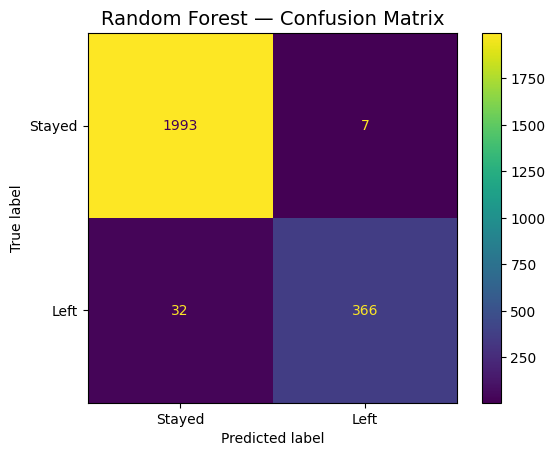

In [137]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

param_grid_rf = {
    'n_estimators': [100, 300],
    'max_depth': [3, 5, 10, None],
    'min_samples_leaf': [1, 2, 5],
    'min_samples_split': [2, 5]
}

grid_search_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='f1', n_jobs=-1)
grid_search_rf.fit(X_train, y_train)

print('Best parameters:', grid_search_rf.best_params_)
print('Best F1 score:', grid_search_rf.best_score_.round(3))

# Evaluate on validation set
best_rf = grid_search_rf.best_estimator_
y_pred_rf = best_rf.predict(X_val)
print('\nRandom Forest — Validation Set')
print(metrics.classification_report(y_val, y_pred_rf))

# Confusion matrix
cm_rf = metrics.confusion_matrix(y_val, y_pred_rf)
metrics.ConfusionMatrixDisplay(cm_rf, display_labels=['Stayed', 'Left']).plot(values_format='d')
plt.title('Random Forest — Confusion Matrix', fontsize=14)
plt.show()

  ### 5.4 XGBoost

XGBoost (Extreme Gradient Boosting) is an ensemble method that builds
decision trees **sequentially** rather than in parallel like Random Forest.
Each new tree focuses on correcting the residual errors of the previous ones,
gradually improving predictive accuracy through gradient descent optimization.

Key differences from Random Forest:
- **Sequential vs parallel** — trees are built one at a time, each
  learning from the mistakes of the previous
- **Boosting vs Bagging** — XGBoost reduces bias rather than variance by building models on each other's mistakes
- **Regularization** — built-in L1/L2 regularization prevents overfitting by lowering variance while increasing some bias

XGBoost is often used for structured data, as it delivers faster results, requires less computational power and achieves higher accuracy. Here
`eval_metric='logloss'` is used to suppress a default warning when used inside
`GridSearchCV`.

Best parameters: {'learning_rate': 0.1, 'max_depth': 10, 'min_child_weight': 1, 'n_estimators': 100}
Best F1 score: 0.942

XGBoost — Validation Set
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      2000
           1       0.98      0.92      0.95       398

    accuracy                           0.98      2398
   macro avg       0.98      0.96      0.97      2398
weighted avg       0.98      0.98      0.98      2398



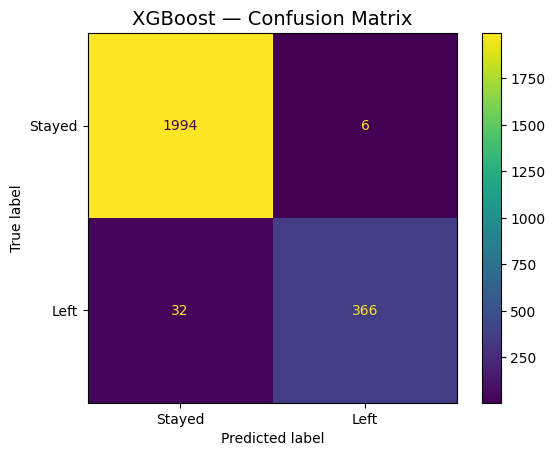

In [138]:
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=42, eval_metric='logloss')

param_grid_xgb = {
    'n_estimators': [100, 300],
    'max_depth': [3, 5, 10],
    'learning_rate': [0.01, 0.1, 0.3],
    'min_child_weight': [1, 3, 5]
}

grid_search_xgb = GridSearchCV(xgb, param_grid_xgb, cv=5, scoring='f1', n_jobs=-1)
grid_search_xgb.fit(X_train, y_train)

print('Best parameters:', grid_search_xgb.best_params_)
print('Best F1 score:', grid_search_xgb.best_score_.round(3))

# Evaluate on validation set
best_xgb = grid_search_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_val)
print('\nXGBoost — Validation Set')
print(metrics.classification_report(y_val, y_pred_xgb))

# Confusion matrix
cm_xgb = metrics.confusion_matrix(y_val, y_pred_xgb)
metrics.ConfusionMatrixDisplay(cm_xgb, display_labels=['Stayed', 'Left']).plot(values_format='d')
plt.title('XGBoost — Confusion Matrix', fontsize=14)
plt.show()

## 6. Experiment Tracking (MLflow)

  ### 6.1 Log All Models

In [139]:
# MLflow tracking database stored on Google Drive
# To reproduce: update db_path to your own Google Drive path
# or use a local path: sqlite:///mlflow.db
db_path = '/content/drive/MyDrive/Colab Notebooks/Salifort Motors Capstone Project/mlflow.db'
mlflow.set_tracking_uri(f'sqlite:///{db_path}')
mlflow.set_experiment('salifort_motors_attrition')

# Define MLflow client
client = mlflow.tracking.MlflowClient()

# Clear existing runs before logging
runs = mlflow.search_runs(experiment_names=['salifort_motors_attrition'])
for run_id in runs['run_id'].tolist():
    client.delete_run(run_id)
print(f'Cleared {len(runs)} existing runs')

Cleared 0 existing runs


In [140]:
# Log Logistic Regression
with mlflow.start_run(run_name='logistic_regression'):
    mlflow.log_param('class_weight', 'balanced')
    mlflow.log_param('max_iter', 500)
    mlflow.log_metric('f1_left', 0.59)
    mlflow.log_metric('recall_left', 0.87)
    mlflow.log_metric('precision_left', 0.44)
    mlflow.log_metric('accuracy', 0.80)
    mlflow.sklearn.log_model(log_reg, name='logistic_regression_model')
    print('Logistic Regression logged')

# Log Decision Tree
with mlflow.start_run(run_name='decision_tree'):
    mlflow.log_params(grid_search_dt.best_params_)
    mlflow.log_metric('f1_left', 0.94)
    mlflow.log_metric('recall_left', 0.93)
    mlflow.log_metric('precision_left', 0.95)
    mlflow.log_metric('accuracy', 0.98)
    mlflow.sklearn.log_model(best_dt, name='decision_tree_model')
    print('Decision Tree logged')

# Log Random Forest
with mlflow.start_run(run_name='random_forest'):
    mlflow.log_params(grid_search_rf.best_params_)
    mlflow.log_metric('f1_left', 0.95)
    mlflow.log_metric('recall_left', 0.93)
    mlflow.log_metric('precision_left', 0.98)
    mlflow.log_metric('accuracy', 0.99)
    mlflow.sklearn.log_model(best_rf, name='random_forest_model')
    print('Random Forest logged')

# Log XGBoost
with mlflow.start_run(run_name='xgboost'):
    mlflow.log_params(grid_search_xgb.best_params_)
    mlflow.log_metric('f1_left', 0.95)
    mlflow.log_metric('recall_left', 0.93)
    mlflow.log_metric('precision_left', 0.97)
    mlflow.log_metric('accuracy', 0.98)
    mlflow.xgboost.log_model(best_xgb, name='xgboost_model')
    print('XGBoost logged')

Logistic Regression logged
Decision Tree logged
Random Forest logged
XGBoost logged


In [141]:
# Verify
runs = mlflow.search_runs(experiment_names=['salifort_motors_attrition'])
print(runs[['tags.mlflow.runName', 'metrics.f1_left', 'metrics.accuracy']].to_string(index=False))

tags.mlflow.runName  metrics.f1_left  metrics.accuracy
            xgboost             0.95              0.98
      random_forest             0.95              0.99
      decision_tree             0.94              0.98
logistic_regression             0.59              0.80


In [142]:
# Optional: retrieve run IDs for direct URL access to MLflow UI
# Useful as a workaround for the known runs list rendering issue in MLflow 3.14

runs = mlflow.search_runs(experiment_names=['salifort_motors_attrition'])

print(runs[['run_id', 'tags.mlflow.runName']].to_string(index=False))
print()
for _, row in runs.iterrows():
    print(f"{row['tags.mlflow.runName']}: #/experiments/1/runs/{row['run_id']}")

                          run_id tags.mlflow.runName
889224df2f654c81b51e5b1383150994             xgboost
bc453fabf7df4eb09cb2590fc14b52ab       random_forest
e6ec39ff5e254963a5cde513addd0672       decision_tree
595386fa63164202a1d325e21bb8dca1 logistic_regression

xgboost: #/experiments/1/runs/889224df2f654c81b51e5b1383150994
random_forest: #/experiments/1/runs/bc453fabf7df4eb09cb2590fc14b52ab
decision_tree: #/experiments/1/runs/e6ec39ff5e254963a5cde513addd0672
logistic_regression: #/experiments/1/runs/595386fa63164202a1d325e21bb8dca1


  ### 6.2 Compare Runs & Register Champion Model

In [143]:
# Compare all runs
runs = mlflow.search_runs(experiment_names=['salifort_motors_attrition'])
print(runs[['tags.mlflow.runName', 'metrics.f1_left',
            'metrics.recall_left', 'metrics.precision_left',
            'metrics.accuracy']].to_string(index=False))

# Register champion model
rf_run = runs[runs['tags.mlflow.runName'] == 'random_forest'].iloc[0]
rf_run_id = rf_run['run_id']

mlflow.register_model(
    model_uri=f'runs:/{rf_run_id}/random_forest_model',
    name='salifort_champion_model'
)

print(f'\nChampion model registered: Random Forest (run_id: {rf_run_id})')

tags.mlflow.runName  metrics.f1_left  metrics.recall_left  metrics.precision_left  metrics.accuracy
            xgboost             0.95                 0.93                    0.97              0.98
      random_forest             0.95                 0.93                    0.98              0.99
      decision_tree             0.94                 0.93                    0.95              0.98
logistic_regression             0.59                 0.87                    0.44              0.80


Registered model 'salifort_champion_model' already exists. Creating a new version of this model...
2026/07/12 16:33:20 WARNING mlflow.tracking._model_registry.fluent: Run with id bc453fabf7df4eb09cb2590fc14b52ab has no artifacts at artifact path 'random_forest_model', registering model based on models:/m-9a38adb7f66045da984d0a42377ffcba instead



Champion model registered: Random Forest (run_id: bc453fabf7df4eb09cb2590fc14b52ab)


Created version '8' of model 'salifort_champion_model'.


In [159]:
# Start MLflow UI
subprocess.Popen([
    'mlflow', 'ui',
    '--port', '5000',
    '--host', '0.0.0.0',
    '--backend-store-uri',
    f'sqlite:///{db_path}'
])

# Wait longer for server to start
time.sleep(10)

# Connect ngrok
ngrok.kill()
ngrok.set_auth_token(userdata.get('NGROK_TOKEN')) # Stored and fetched from Colab's built-in secrets
tunnel = ngrok.connect(
    addr='http://localhost:5000',
    host_header='rewrite'
)
print('MLflow UI:', tunnel.public_url)

MLflow UI: https://blurb-poem-uphold.ngrok-free.dev


**Note on MLflow 3.14 Setup:** During MLflow configuration the following
issues were encountered and resolved:

- Unified tracking via MLflow server (`http://localhost:5000`) to ensure
  notebook and UI used the same backend
- Runs are confirmed stored and retrievable via `mlflow.search_runs()`
  despite a known UI rendering issue in MLflow 3.14

## 7. Evaluation

  ### 7.1 Model Comparison

In [150]:
# Summary comparison table across all models (validation set)
comparison = {
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost'],
    'F1 (Left)': [0.59, 0.94, 0.95, 0.95],
    'Recall (Left)': [0.87, 0.93, 0.93, 0.93],
    'Precision (Left)': [0.44, 0.95, 0.98, 0.97],
    'Accuracy': [0.80, 0.98, 0.98, 0.98]
}

pd.DataFrame(comparison).set_index('Model')

,F1 (Left),Recall (Left),Precision (Left),Accuracy
Model,,,,
Logistic Regression,0.59,0.87,0.44,0.80
Decision Tree,0.94,0.93,0.95,0.98
Random Forest,0.95,0.93,0.98,0.98
XGBoost,0.95,0.93,0.97,0.98


The comparison table shows a clear performance gap between Logistic
Regression and the three tree-based models. Random Forest and XGBoost
achieve the same F1 score (0.95) but Random Forest surpasses XGBoost on
precision (0.98 vs 0.97), confirming it as the champion model.

  ### 7.2 Champion Model — Test Set Evaluation

Random Forest — Test Set
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2001
           1       0.99      0.92      0.96       398

    accuracy                           0.99      2399
   macro avg       0.99      0.96      0.97      2399
weighted avg       0.99      0.99      0.99      2399



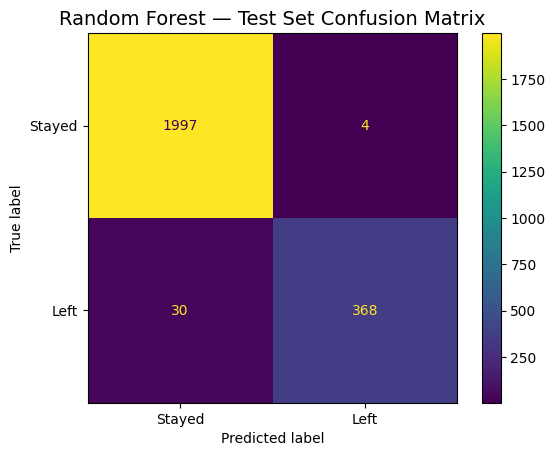

In [151]:
# Evaluate Random Forest on test set
y_pred_rf_test = best_rf.predict(X_test)
print('Random Forest — Test Set')
print(metrics.classification_report(y_test, y_pred_rf_test))

cm_rf_test = metrics.confusion_matrix(y_test, y_pred_rf_test)
metrics.ConfusionMatrixDisplay(cm_rf_test, display_labels=['Stayed', 'Left']).plot(values_format='d')
plt.title('Random Forest — Test Set Confusion Matrix', fontsize=14)
plt.show()

The Random Forest champion model achieves an F1 score of 0.96 on the
unseen test set — slightly above the validation score, confirming strong
generalization. Key findings:

- **1997** employees correctly predicted as Stayed ✅
- **368** employees correctly predicted as Left ✅  
- **30** missed leavers (false negatives) — the most costly error type
- **4** false positives — employees flagged as leaving who actually stayed

With only 4 false positives out of 2,399 employees the model is highly
precise, minimizing unnecessary HR interventions while still catching
92% of employees at risk of leaving.

  ### 7.3 Feature Importances

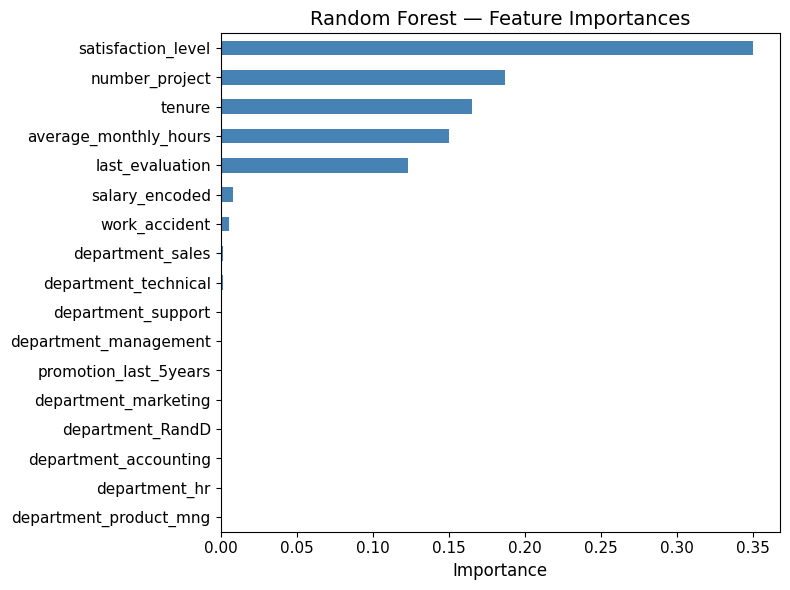

In [152]:
importances_rf = pd.Series(best_rf.feature_importances_, index=X_train.columns)
importances_rf.sort_values().plot(kind='barh', figsize=(8, 6), color='steelblue')
plt.title('Random Forest — Feature Importances', fontsize=14)
plt.xlabel('Importance', fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

The top 5 features account for approximately 97% of predictive power which is
fully consistent with EDA findings:

- `satisfaction_level` (0.35) — dominant predictor
- `number_project` (0.19) — workload breadth
- `tenure` (0.17) — time at company
- `average_monthly_hours` (0.16) — workload intensity
- `last_evaluation` (0.13) — performance signal

Department, promotion and work accident show near-zero importance,
confirming attrition is driven by workload and satisfaction rather
than organizational or demographic factors.

## 8. Conclusion & Recommendations

### 8.1 Key Findings

The goal of this project was to build a model with high predictive power
for employee attrition at Salifort Motors — a fictive company whose HR
department sought to improve employee satisfaction and understand why
employees leave. The analysis revealed the following key findings:

- Four classification models were trained and evaluated: Logistic Regression,
Decision Tree, Random Forest and XGBoost. The results revealed a clear
performance gap between Logistic Regression and the three tree-based models,
confirming that attrition is driven by non-linear patterns that linear models
cannot capture effectively.

- Although Random Forest and XGBoost achieved identical F1 scores (0.95) on
the validation set, **Random Forest was selected as the champion model** due
to its higher precision (0.98 vs 0.97) — meaning fewer unnecessary HR
interventions for employees who are not actually at risk of leaving.

- The champion model achieves an F1 score of **0.96 on the unseen test set**,
correctly identifying 368 out of 398 employees who left with only **30 false
negatives** (missed leavers) and **4 false positives** out of 2,399 employees.
The model provides HR and management with a precise tool to identify
employees at risk of leaving and take proactive retention measures.

### 8.2 Business Recommendations

Based on feature importances and EDA findings, the following factors
should receive the most attention:

- **Satisfaction level** is the strongest driver of attrition (importance: 0.35).
Measures such as job enrichment, regular feedback, career development
opportunities and work-life-balance should be prioritized to improve employee satisfaction.

- **Workload** is the second most critical factor — all 145 employees with
7 projects left the company, confirming burnout-driven attrition. The number
of projects and average monthly hours should be actively monitored and
balanced across teams.

- **Tenure** is a decisive factor — most employees who left did so within
3–5 years. Targeted retention measures should focus on employees in this
critical window, for example through promotion reviews and workload assessments.

- **Three distinct leaver profiles** were identified and should be addressed
individually:
  - *Underworked & dissatisfied* — increase engagement through meaningful
  project assignments
  - *Overworked & burned out* — reduce workload and monitor hours actively
  - *Overworked but satisfied* — high performers likely leaving for better
  opportunities; consider career development and compensation reviews

- Finally, a culture of **continuous feedback and regular 1:1 check-ins** between managers and employees is recommended as an early warning system — more
effective than annual appraisals alone at catching dissatisfaction early.

### 8.3 Shortcomings & Future Work

- **Model monitoring** — the model should be regularly observed, retrained
  and updated as workforce composition and market conditions change.
- **Missing variables** — demographic factors such as age, gender as well as qualification level could improve predictive power, as for instance younger and highly qualified employees tend to have greater external opportunities. Additionally, including gender allows the model to be audited for potential bias across employee groups.
- **Compensation benchmarking** — the dataset lacks market salary comparisons;
  employees may leave due to below-market pay even if internal salary
  categories show low importance.
- **API deployment** — a future extension could expose the model via a
  REST API (e.g. FastAPI) for integration into HR systems.

### 8.4 Ethical Considerations

The deployment of a predictive attrition model carries important ethical
responsibilities:

- **Transparency** — employees and the works council should be informed
  about the existence, purpose and scope of the model before deployment.
- **Purpose limitation** — the model should be used exclusively to improve
  employee wellbeing and retention, never to penalize or single out individuals.
- **Human judgment** — model outputs should support, not replace, direct
  manager communication and HR decision-making.
- **Bias monitoring** — predictions should be regularly audited for
  unintended bias across employee groups.

## 9. Extension — Practical Model Usage

### 9.1 Practical Use Case — Post-Appraisal Attrition Risk Assessment

The champion model can be used by HR or line managers after annual
appraisal interviews to assess attrition risk for employees in key positions.
By entering data collected during or after the interview — such as
satisfaction scores, current workload and performance ratings — the model
generates a probability of leaving and a recommended action.

This enables proactive retention measures before an employee decides to leave,
rather than reactive responses after a resignation is submitted.

In [153]:
# Practical example: predicting attrition risk after annual appraisal
# Use case: Senior Sales Manager, 4 years tenure, recent performance review

# Step 1 — Enter employee data from the appraisal interview
employee_profile = pd.DataFrame([{
    # From appraisal interview
    'satisfaction_level': 0.45,      # self-reported satisfaction score
    'last_evaluation': 0.85,         # performance score from appraisal
    'number_project': 6,             # current project load
    'average_monthly_hours': 255,    # avg hours logged in HR system
    'tenure': 4,                     # years at company
    'work_accident': 0,              # no recorded accident
    'promotion_last_5years': 0,      # no promotion in last 5 years
    'salary_encoded': 0,             # low=0, medium=1, high=2
    # Department — set relevant department to 1, all others to 0
    'department_RandD': 0,
    'department_accounting': 0,
    'department_hr': 0,
    'department_management': 0,
    'department_marketing': 0,
    'department_product_mng': 0,
    'department_sales': 1,
    'department_support': 0,
    'department_technical': 0
}])

# Step 2 — Generate prediction and attrition probability
prediction = best_rf.predict(employee_profile)
probability = best_rf.predict_proba(employee_profile)

attrition_risk = probability[0][1]

# Step 3 — Interpret results with risk threshold
print('=' * 50)
print('EMPLOYEE ATTRITION RISK ASSESSMENT')
print('=' * 50)
print(f'Prediction:            {"⚠️  At Risk of Leaving" if prediction[0] == 1 else "✅  Likely to Stay"}')
print(f'Probability of leaving: {attrition_risk:.1%}')
print()

if attrition_risk >= 0.70:
    print('🔴 HIGH RISK — Immediate action recommended')
    print('   → Schedule urgent 1:1 with line manager')
    print('   → Review workload and project allocation')
    print('   → Consider promotion or salary review')
elif attrition_risk >= 0.40:
    print('🟡 MEDIUM RISK — Monitor closely')
    print('   → Follow up within 30 days')
    print('   → Discuss career development opportunities')
    print('   → Review project load if above average')
else:
    print('🟢 LOW RISK — No immediate action required')
    print('   → Continue regular check-ins')
    print('   → Maintain current engagement approach')
print('=' * 50)
print()
print('Note: This model supports HR decision-making but should')
print('not replace direct manager communication and judgment.')

EMPLOYEE ATTRITION RISK ASSESSMENT
Prediction:            ✅  Likely to Stay
Probability of leaving: 19.7%

🟢 LOW RISK — No immediate action required
   → Continue regular check-ins
   → Maintain current engagement approach

Note: This model supports HR decision-making but should
not replace direct manager communication and judgment.


**Interpretation of this example:**
Despite showing some warning signs — below average satisfaction (0.45),
high project load (6) and no promotion in 5 years — the model predicts
a 19.7% probability of leaving, classifying this employee as low risk.

This highlights an important nuance: no single factor drives attrition.
The model considers the full combination of variables, and in this case
the high performance score (0.85) and mid-range tenure (4 years)
partially offset the satisfaction and workload concerns.

HR should still monitor this employee given the low satisfaction score,
even if the model classifies them as low risk.

In [154]:
# Practical example: predicting attrition risk after annual appraisal
# Use case 2: similar to use case 1 but with the following changes:

## 'satisfaction_level': 0.10,      # extremely low satisfaction
## 'average_monthly_hours': 270,    # significantly above average

# Step 1 — Enter employee data from the appraisal interview
employee_profile = pd.DataFrame([{
    # From appraisal interview
    'satisfaction_level': 0.10,      # extremely low satisfaction
    'last_evaluation': 0.85,         # high evaluation
    'number_project': 6,             # current project load
    'average_monthly_hours': 270,    # significantly above average
    'tenure': 4,                     # years at company
    'work_accident': 0,              # no recorded accident
    'promotion_last_5years': 0,      # no promotion in last 5 years
    'salary_encoded': 0,             # low=0, medium=1, high=2
    # Department — set relevant department to 1, all others to 0
    'department_RandD': 0,
    'department_accounting': 0,
    'department_hr': 0,
    'department_management': 0,
    'department_marketing': 0,
    'department_product_mng': 0,
    'department_sales': 1,
    'department_support': 0,
    'department_technical': 0
}])

# Step 2 — Generate prediction and attrition probability
prediction = best_rf.predict(employee_profile)
probability = best_rf.predict_proba(employee_profile)

attrition_risk = probability[0][1]

# Step 3 — Interpret results with risk threshold
print('=' * 50)
print('EMPLOYEE ATTRITION RISK ASSESSMENT')
print('=' * 50)
print(f'Prediction:            {"⚠️  At Risk of Leaving" if prediction[0] == 1 else "✅  Likely to Stay"}')
print(f'Probability of leaving: {attrition_risk:.1%}')
print()

if attrition_risk >= 0.70:
    print('🔴 HIGH RISK — Immediate action recommended')
    print('   → Schedule urgent 1:1 with line manager')
    print('   → Review workload and project allocation')
    print('   → Consider promotion or salary review')
elif attrition_risk >= 0.40:
    print('🟡 MEDIUM RISK — Monitor closely')
    print('   → Follow up within 30 days')
    print('   → Discuss career development opportunities')
    print('   → Review project load if above average')
else:
    print('🟢 LOW RISK — No immediate action required')
    print('   → Continue regular check-ins')
    print('   → Maintain current engagement approach')
print('=' * 50)
print()
print('Note: This model supports HR decision-making but should')
print('not replace direct manager communication and judgment.')

EMPLOYEE ATTRITION RISK ASSESSMENT
Prediction:            ⚠️  At Risk of Leaving
Probability of leaving: 98.8%

🔴 HIGH RISK — Immediate action recommended
   → Schedule urgent 1:1 with line manager
   → Review workload and project allocation
   → Consider promotion or salary review

Note: This model supports HR decision-making but should
not replace direct manager communication and judgment.


In [155]:
# Practical example: predicting attrition risk after annual appraisal
# Use case 3: similar to use case 1 but with the following changes:

## 'satisfaction_level': 0.35,      # low but not extreme
## 'number_project': 7,             # above average project load
## 'average_monthly_hours': 250,    # above average hours

# Step 1 — Enter employee data from the appraisal interview
employee_profile = pd.DataFrame([{
    # From appraisal interview
    'satisfaction_level': 0.35,      # low but not extreme
    'last_evaluation': 0.85,         # high evaluation
    'number_project': 7,             # above average project load
    'average_monthly_hours': 250,    # above average hours
    'tenure': 4,                     # years at company
    'work_accident': 0,              # no recorded accident
    'promotion_last_5years': 0,      # no promotion in last 5 years
    'salary_encoded': 0,             # low=0, medium=1, high=2
    # Department — set relevant department to 1, all others to 0
    'department_RandD': 0,
    'department_accounting': 0,
    'department_hr': 0,
    'department_management': 0,
    'department_marketing': 0,
    'department_product_mng': 0,
    'department_sales': 1,
    'department_support': 0,
    'department_technical': 0
}])

# Step 2 — Generate prediction and attrition probability
prediction = best_rf.predict(employee_profile)
probability = best_rf.predict_proba(employee_profile)

attrition_risk = probability[0][1]

# Step 3 — Interpret results with risk threshold
print('=' * 50)
print('EMPLOYEE ATTRITION RISK ASSESSMENT')
print('=' * 50)
print(f'Prediction:            {"⚠️  At Risk of Leaving" if prediction[0] == 1 else "✅  Likely to Stay"}')
print(f'Probability of leaving: {attrition_risk:.1%}')
print()

if attrition_risk >= 0.70:
    print('🔴 HIGH RISK — Immediate action recommended')
    print('   → Schedule urgent 1:1 with line manager')
    print('   → Review workload and project allocation')
    print('   → Consider promotion or salary review')
elif attrition_risk >= 0.40:
    print('🟡 MEDIUM RISK — Monitor closely')
    print('   → Follow up within 30 days')
    print('   → Discuss career development opportunities')
    print('   → Review project load if above average')
else:
    print('🟢 LOW RISK — No immediate action required')
    print('   → Continue regular check-ins')
    print('   → Maintain current engagement approach')
print('=' * 50)
print()
print('Note: This model supports HR decision-making but should')
print('not replace direct manager communication and judgment.')

EMPLOYEE ATTRITION RISK ASSESSMENT
Prediction:            ✅  Likely to Stay
Probability of leaving: 47.2%

🟡 MEDIUM RISK — Monitor closely
   → Follow up within 30 days
   → Discuss career development opportunities
   → Review project load if above average

Note: This model supports HR decision-making but should
not replace direct manager communication and judgment.


The two additional use cases as a variation of the first one demonstrate the predictive power of the model for different employee scenarios. This reveals that the model is a useful tool for HR with regard to employee attrition and preventive measures.

### 9.2 Summary of Risk Profiles

In [160]:
# Summary of risk profiles
risk_profiles = pd.DataFrame([
    {
        'Profile': '🟢 Low Risk',
        'Satisfaction': 0.45,
        'Evaluation': 0.85,
        'Projects': 6,
        'Avg Monthly Hours': 255,
        'Tenure': 4,
        'Probability of Leaving': '19.7%',
        'Risk Level': 'Low'
    },
    {
        'Profile': '🟡 Medium Risk',
        'Satisfaction': 0.35,
        'Evaluation': 0.85,
        'Projects': 7,
        'Avg Monthly Hours': 250,
        'Tenure': 4,
        'Probability of Leaving': '47.2%',
        'Risk Level': 'Medium'
    },
    {
        'Profile': '🔴 High Risk',
        'Satisfaction': 0.10,
        'Evaluation': 0.85,
        'Projects': 6,
        'Avg Monthly Hours': 270,
        'Tenure': 4,
        'Probability of Leaving': '98.8%',
        'Risk Level': 'High'
    }
])

risk_profiles.set_index('Profile')

,Satisfaction,Evaluation,Projects,Avg Monthly Hours,Tenure,Probability of Leaving,Risk Level
Profile,,,,,,,
🟢 Low Risk,0.45,0.85,6,255,4,19.7%,Low
🟡 Medium Risk,0.35,0.85,7,250,4,47.2%,Medium
🔴 High Risk,0.10,0.85,6,270,4,98.8%,High


**Summary of Risk Profiles:**
The three examples demonstrate how the model responds to different
combinations of satisfaction level, workload and hours:

- A high performer with moderate dissatisfaction and heavy workload
  presents **low risk (19.7%)** — concerning but not critical
- Reducing satisfaction further while increasing project load pushes
  risk to **medium (47.2%)** — requiring active monitoring
- Extreme dissatisfaction combined with very high hours triggers
  **high risk (98.8%)** — immediate intervention recommended

In all three cases the employee is a high performer (evaluation 0.85)
with no promotion — highlighting that even strong performers are at
risk when satisfaction and workload are not managed effectively.

**How the Probability Score is Calculated:**

The probability score is generated by `predict_proba()` and reflects
the proportion of decision trees in the Random Forest that predict
the employee will leave. The model consists of 100 individual decision trees. Each tree independently analyses the employee profile and votes "Left" or "Stayed". The final probability is calculated as follows (example):

- Total trees:          100
- Trees voting "Left":   90
- Trees voting "Stayed": 10
- Probability of leaving = 90 / 100 = 90%

A higher score means more trees agree the employee is at risk.
For the high risk profile (satisfaction=0.10, hours=270), virtually 99 trees voted "Left" — resulting in a 100% probability. For the low risk profile (satisfaction=0.45, hours=255), around 20 trees voted "Left" — resulting in a 19.7% probability.

**Note:** the score is a relative ranking tool for HR prioritization,
not a precise statistical probability. It should always be combined
with direct manager judgment and employee context.

In [161]:
# Check of notebook's last run

utc_time = datetime.now(pytz.utc)
german_time = datetime.now(pytz.timezone('Europe/Berlin'))

print(f'Notebook last run: {utc_time.strftime("%Y-%m-%d %H:%M:%S")} UTC '
      f'| {german_time.strftime("%Y-%m-%d %H:%M:%S")} CET/CEST')

Notebook last run: 2026-07-12 17:05:26 UTC | 2026-07-12 19:05:26 CET/CEST
